In [1]:
# - Librairies -----
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from nucleo.io.reading import reading_all_parquet

In [2]:
# - Getting the data -----
root_fact = "/home/nicolas/Documents/Workspace/nucleo/outputs/FACT__PSMN__2026-05-21"
df_fact = reading_all_parquet(root_fact)
df_fact.group_by(["mode", "land", "l", "alphar", "Kp"])
print(df_fact)

/home/nicolas/Documents/Workspace/nucleo/src/nucleo/io/reading.py:143: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  cols = _scalar_column_names(lf.schema)


shape: (5_346, 61)
┌──────┬──────┬──────────┬───────┬───┬───────┬──────────┬──────────┬───────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ dx_mp ┆ dt_mean  ┆ dt_med   ┆ dt_mp │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---   ┆ ---      ┆ ---      ┆ ---   │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ f64   ┆ f64      ┆ f64      ┆ f64   │
╞══════╪══════╪══════════╪═══════╪═══╪═══════╪══════════╪══════════╪═══════╡
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 91.5  ┆ 0.999241 ┆ 0.837845 ┆ 0.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 73.5  ┆ 0.996669 ┆ 0.836689 ┆ 0.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 98.5  ┆ 0.998465 ┆ 0.838713 ┆ 0.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 74.5  ┆ 1.001269 ┆ 0.840778 ┆ 0.5   │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 82.5  ┆ 1.000149 ┆ 0.839989 ┆ 0.5   │
│ …    ┆ …    ┆ …        ┆ …     ┆ … ┆ …     ┆ …        ┆ …        ┆ …     │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 85.5  ┆ 1.000216 ┆ 0.83942  ┆ 0.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 77.5  ┆ 1.002424 ┆

# Passive

In [3]:
# - Data -----
df_passive = df_fact.filter(pl.col("mode") == "passfull")
print(df_passive)
print(df_passive.columns)

shape: (1_782, 61)
┌──────┬──────┬──────────┬───────┬───┬───────┬──────────┬──────────┬───────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ dx_mp ┆ dt_mean  ┆ dt_med   ┆ dt_mp │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---   ┆ ---      ┆ ---      ┆ ---   │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ f64   ┆ f64      ┆ f64      ┆ f64   │
╞══════╪══════╪══════════╪═══════╪═══╪═══════╪══════════╪══════════╪═══════╡
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 73.5  ┆ 0.999307 ┆ 0.839748 ┆ 0.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 94.5  ┆ 0.999359 ┆ 0.837357 ┆ 0.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 84.5  ┆ 0.997639 ┆ 0.838089 ┆ 0.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 79.5  ┆ 0.99962  ┆ 0.835572 ┆ 0.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 78.5  ┆ 0.996656 ┆ 0.836929 ┆ 0.5   │
│ …    ┆ …    ┆ …        ┆ …     ┆ … ┆ …     ┆ …        ┆ …        ┆ …     │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 85.5  ┆ 1.000216 ┆ 0.83942  ┆ 0.5   │
│ 2S   ┆ true ┆ passfull ┆ false ┆ … ┆ 77.5  ┆ 1.002424 ┆

In [4]:
columns = [
    'algo', 'fact', 'mode', 'dstr', 
    'land', 's', 'l', 'bpmin', 
    'mu', 'theta', 'alphaf', 
    'alphao', 'beta', 'rcapt', 'rrest', 'alphac', 'alphad', 
    'alphar', 'krel', 'Kp', 'Kz'
]

for col in columns:
    print(f"Unique values of {col} : {np.unique(df_passive[col])}")

landscapes = ["periodic", "random"]
df_passive = df_passive.filter(
    (pl.col("Kz") == 0.0) &
    (pl.col("land").is_in(landscapes))
)
print(df_passive)

Unique values of algo : ['2S']
Unique values of fact : [ True]
Unique values of mode : ['passfull']
Unique values of dstr : [False]
Unique values of land : ['homogen' 'periodic' 'random']
Unique values of s : [35]
Unique values of l : [ 10  35 100]
Unique values of bpmin : [0]
Unique values of mu : [150]
Unique values of theta : [100]
Unique values of alphaf : [1.]
Unique values of alphao : [0.]
Unique values of beta : [0.]
Unique values of rcapt : [2.]
Unique values of rrest : [2.]
Unique values of alphac : [0.6]
Unique values of alphad : [0.]
Unique values of alphar : [0.  0.2 0.4 0.6 0.8 1. ]
Unique values of krel : [1.]
Unique values of Kp : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Unique values of Kz : [0.  0.5 1. ]
shape: (396, 61)
┌──────┬──────┬──────────┬───────┬───┬───────┬──────────┬──────────┬───────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ dx_mp ┆ dt_mean  ┆ dt_med   ┆ dt_mp │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---   ┆ ---      ┆ ---      ┆ ---   │
│ str  ┆ bool ┆ 

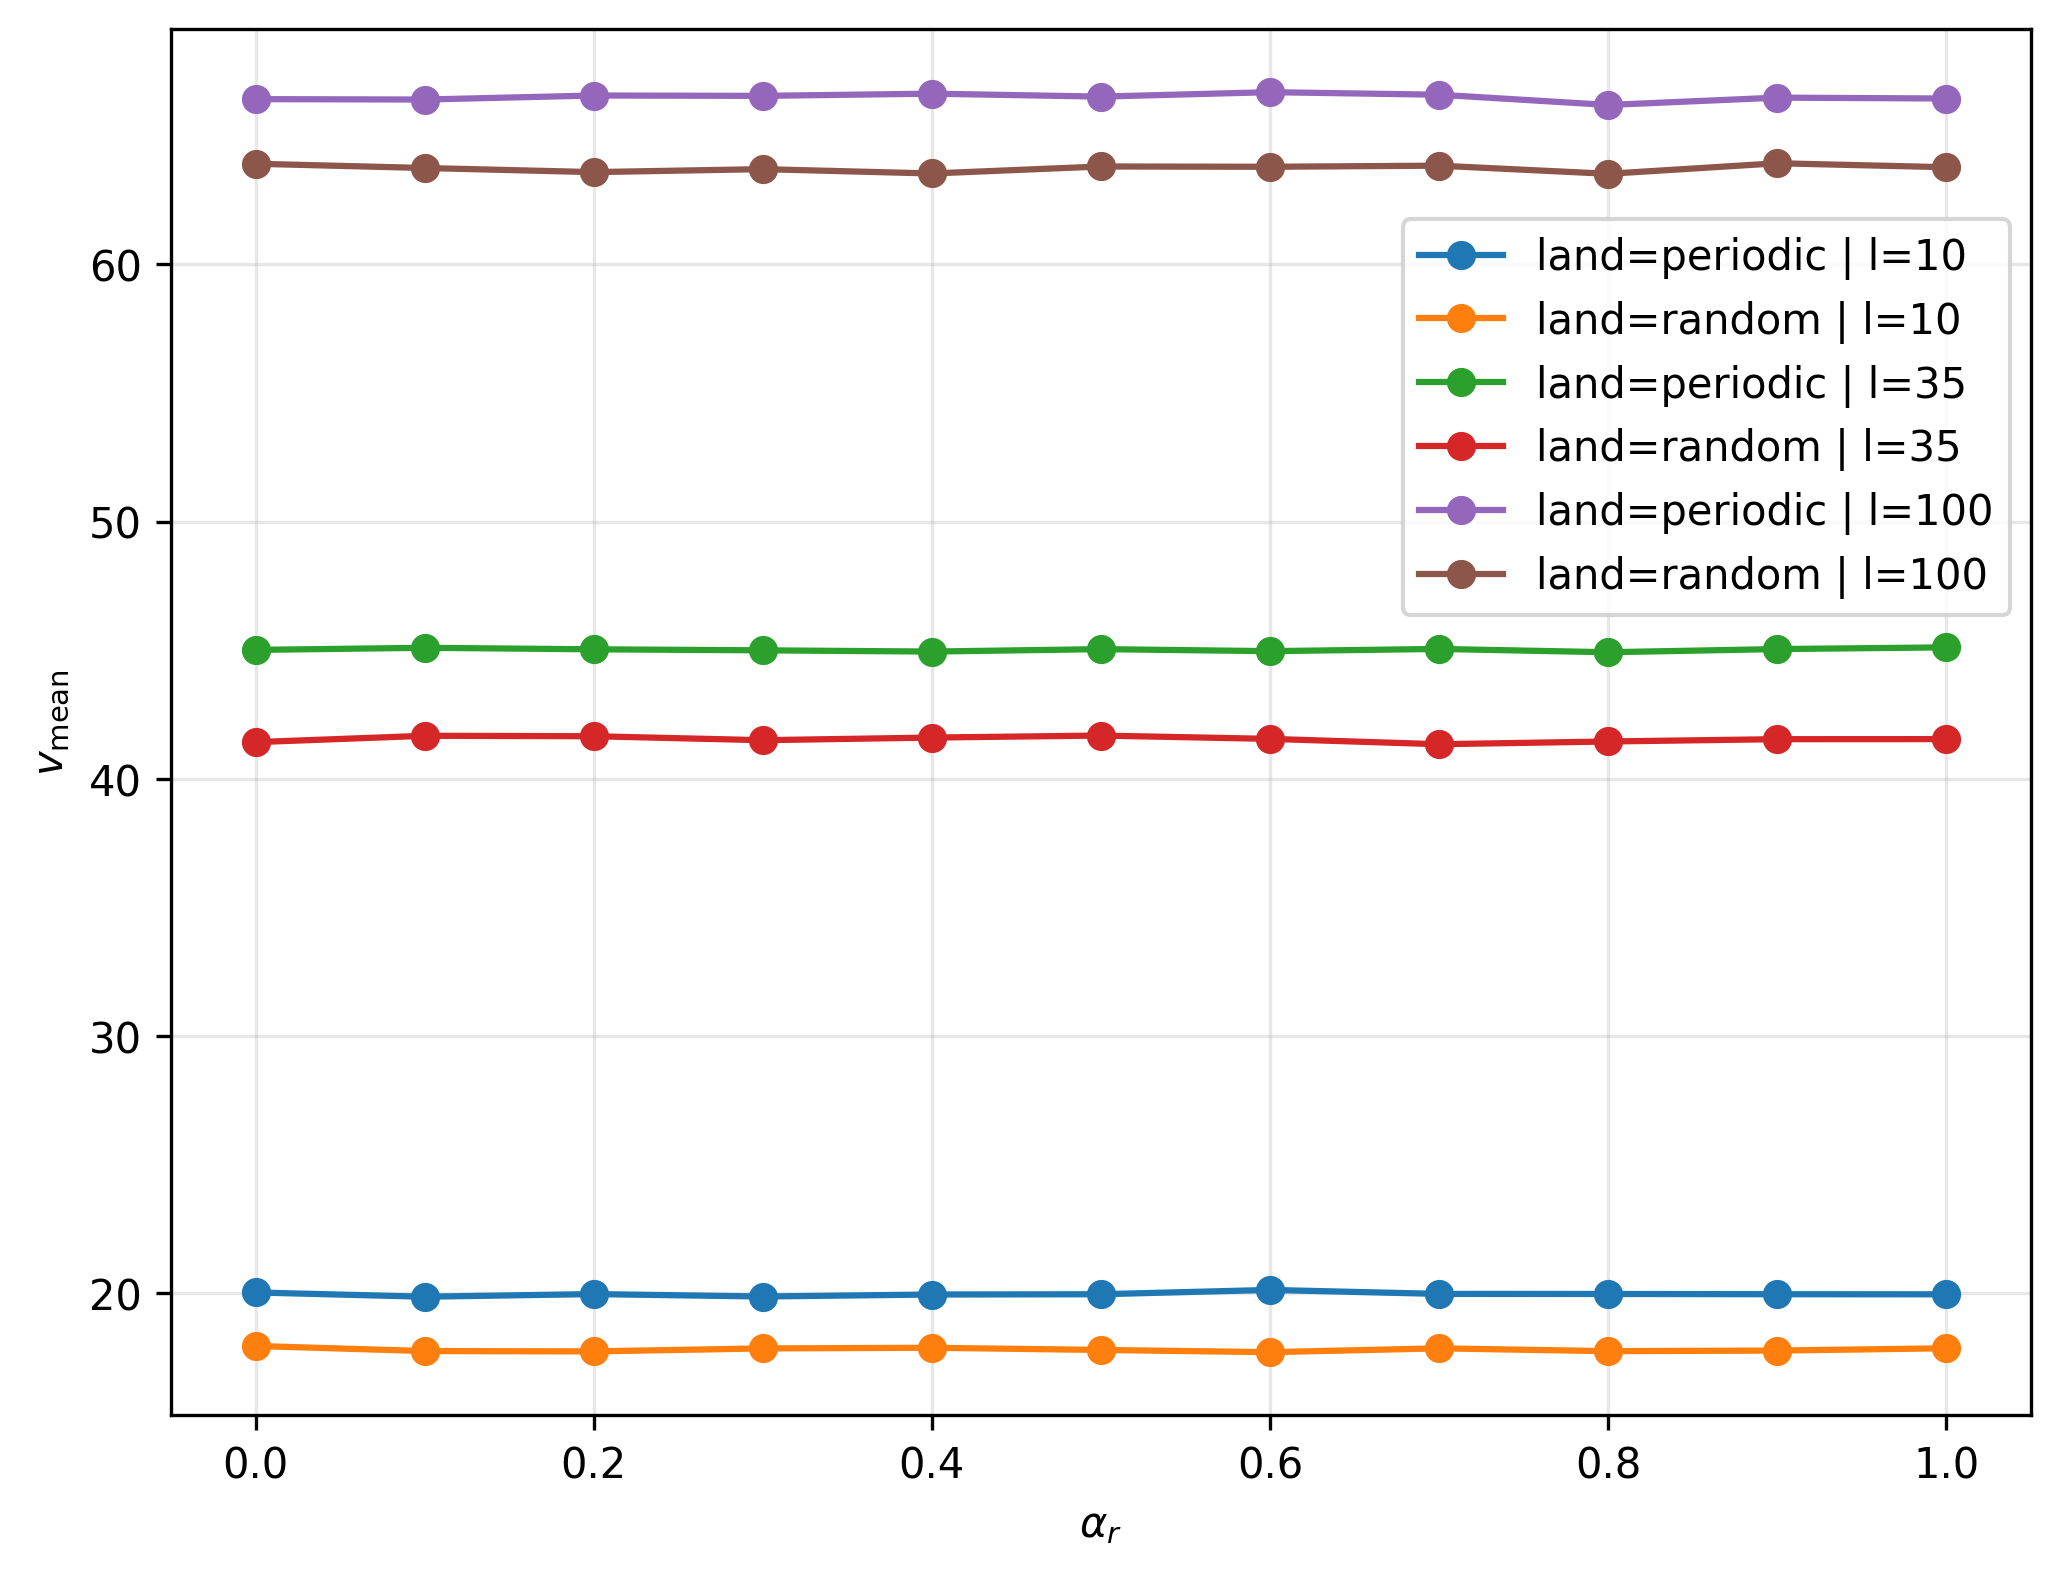

In [5]:
plt.figure(figsize=(8,6), dpi=300)

alphar = 0

ls = np.unique(df_passive["l"].to_numpy())

for l in ls:

    for land in landscapes :

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("alphar") == alphar) &
            (pl.col("l") == l)
        )

        Kp      = df_land["Kp"].to_numpy()
        v_mean  = df_land["v_mean"].to_numpy()

        plt.plot(Kp, v_mean, label=f"land={land} | l={l}", marker = "o")

# plt.title(rf"$l={l}~|~\alpha_r = {alphar}$")
plt.xlabel(r"$\alpha_r$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend(
    loc="center right",
    bbox_to_anchor=(1, 0.72)
)
plt.show()

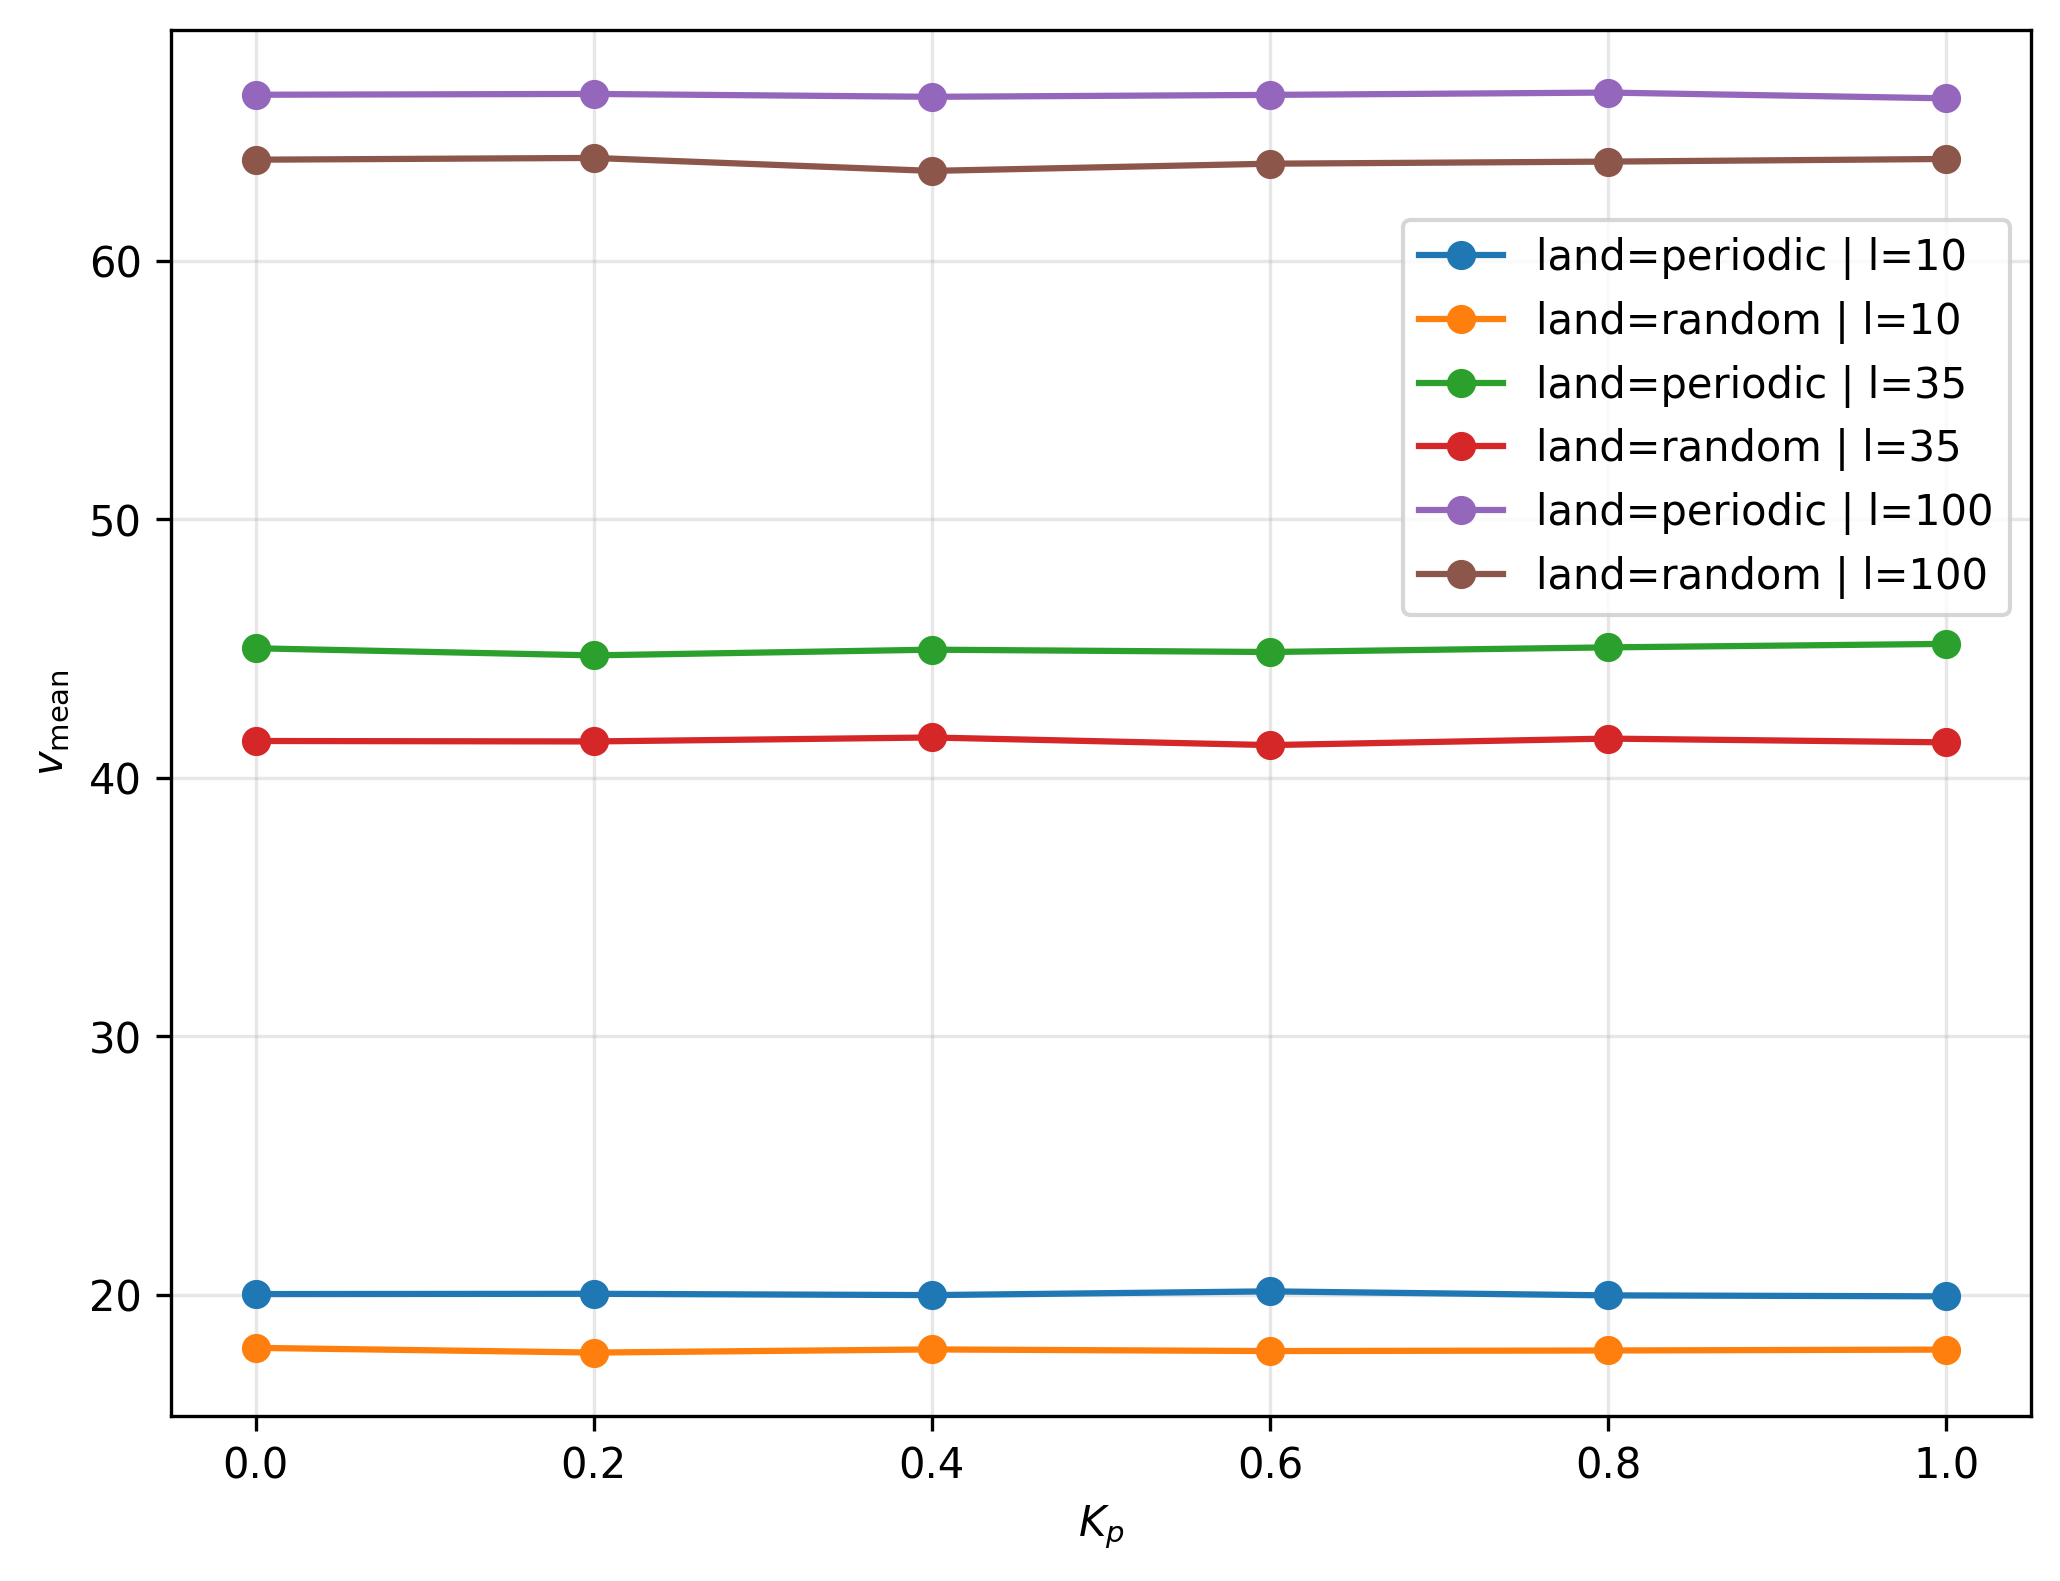

In [6]:
plt.figure(figsize=(8,6), dpi=300)

Kp = 0
ls = np.unique(df_passive["l"].to_numpy())

for l in ls:

    for land in landscapes :

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("Kp") == Kp) &
            (pl.col("l") == l)
        )

        alphar  = df_land["alphar"].to_numpy()
        v_mean  = df_land["v_mean"].to_numpy()

        plt.plot(alphar, v_mean, label=f"land={land} | l={l}", marker = "o")

# plt.title(rf"$l={l}~|~K_p = {Kp}$")
plt.xlabel(r"$K_p$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend(
    loc="center right",
    bbox_to_anchor=(1, 0.72)
)
plt.show()

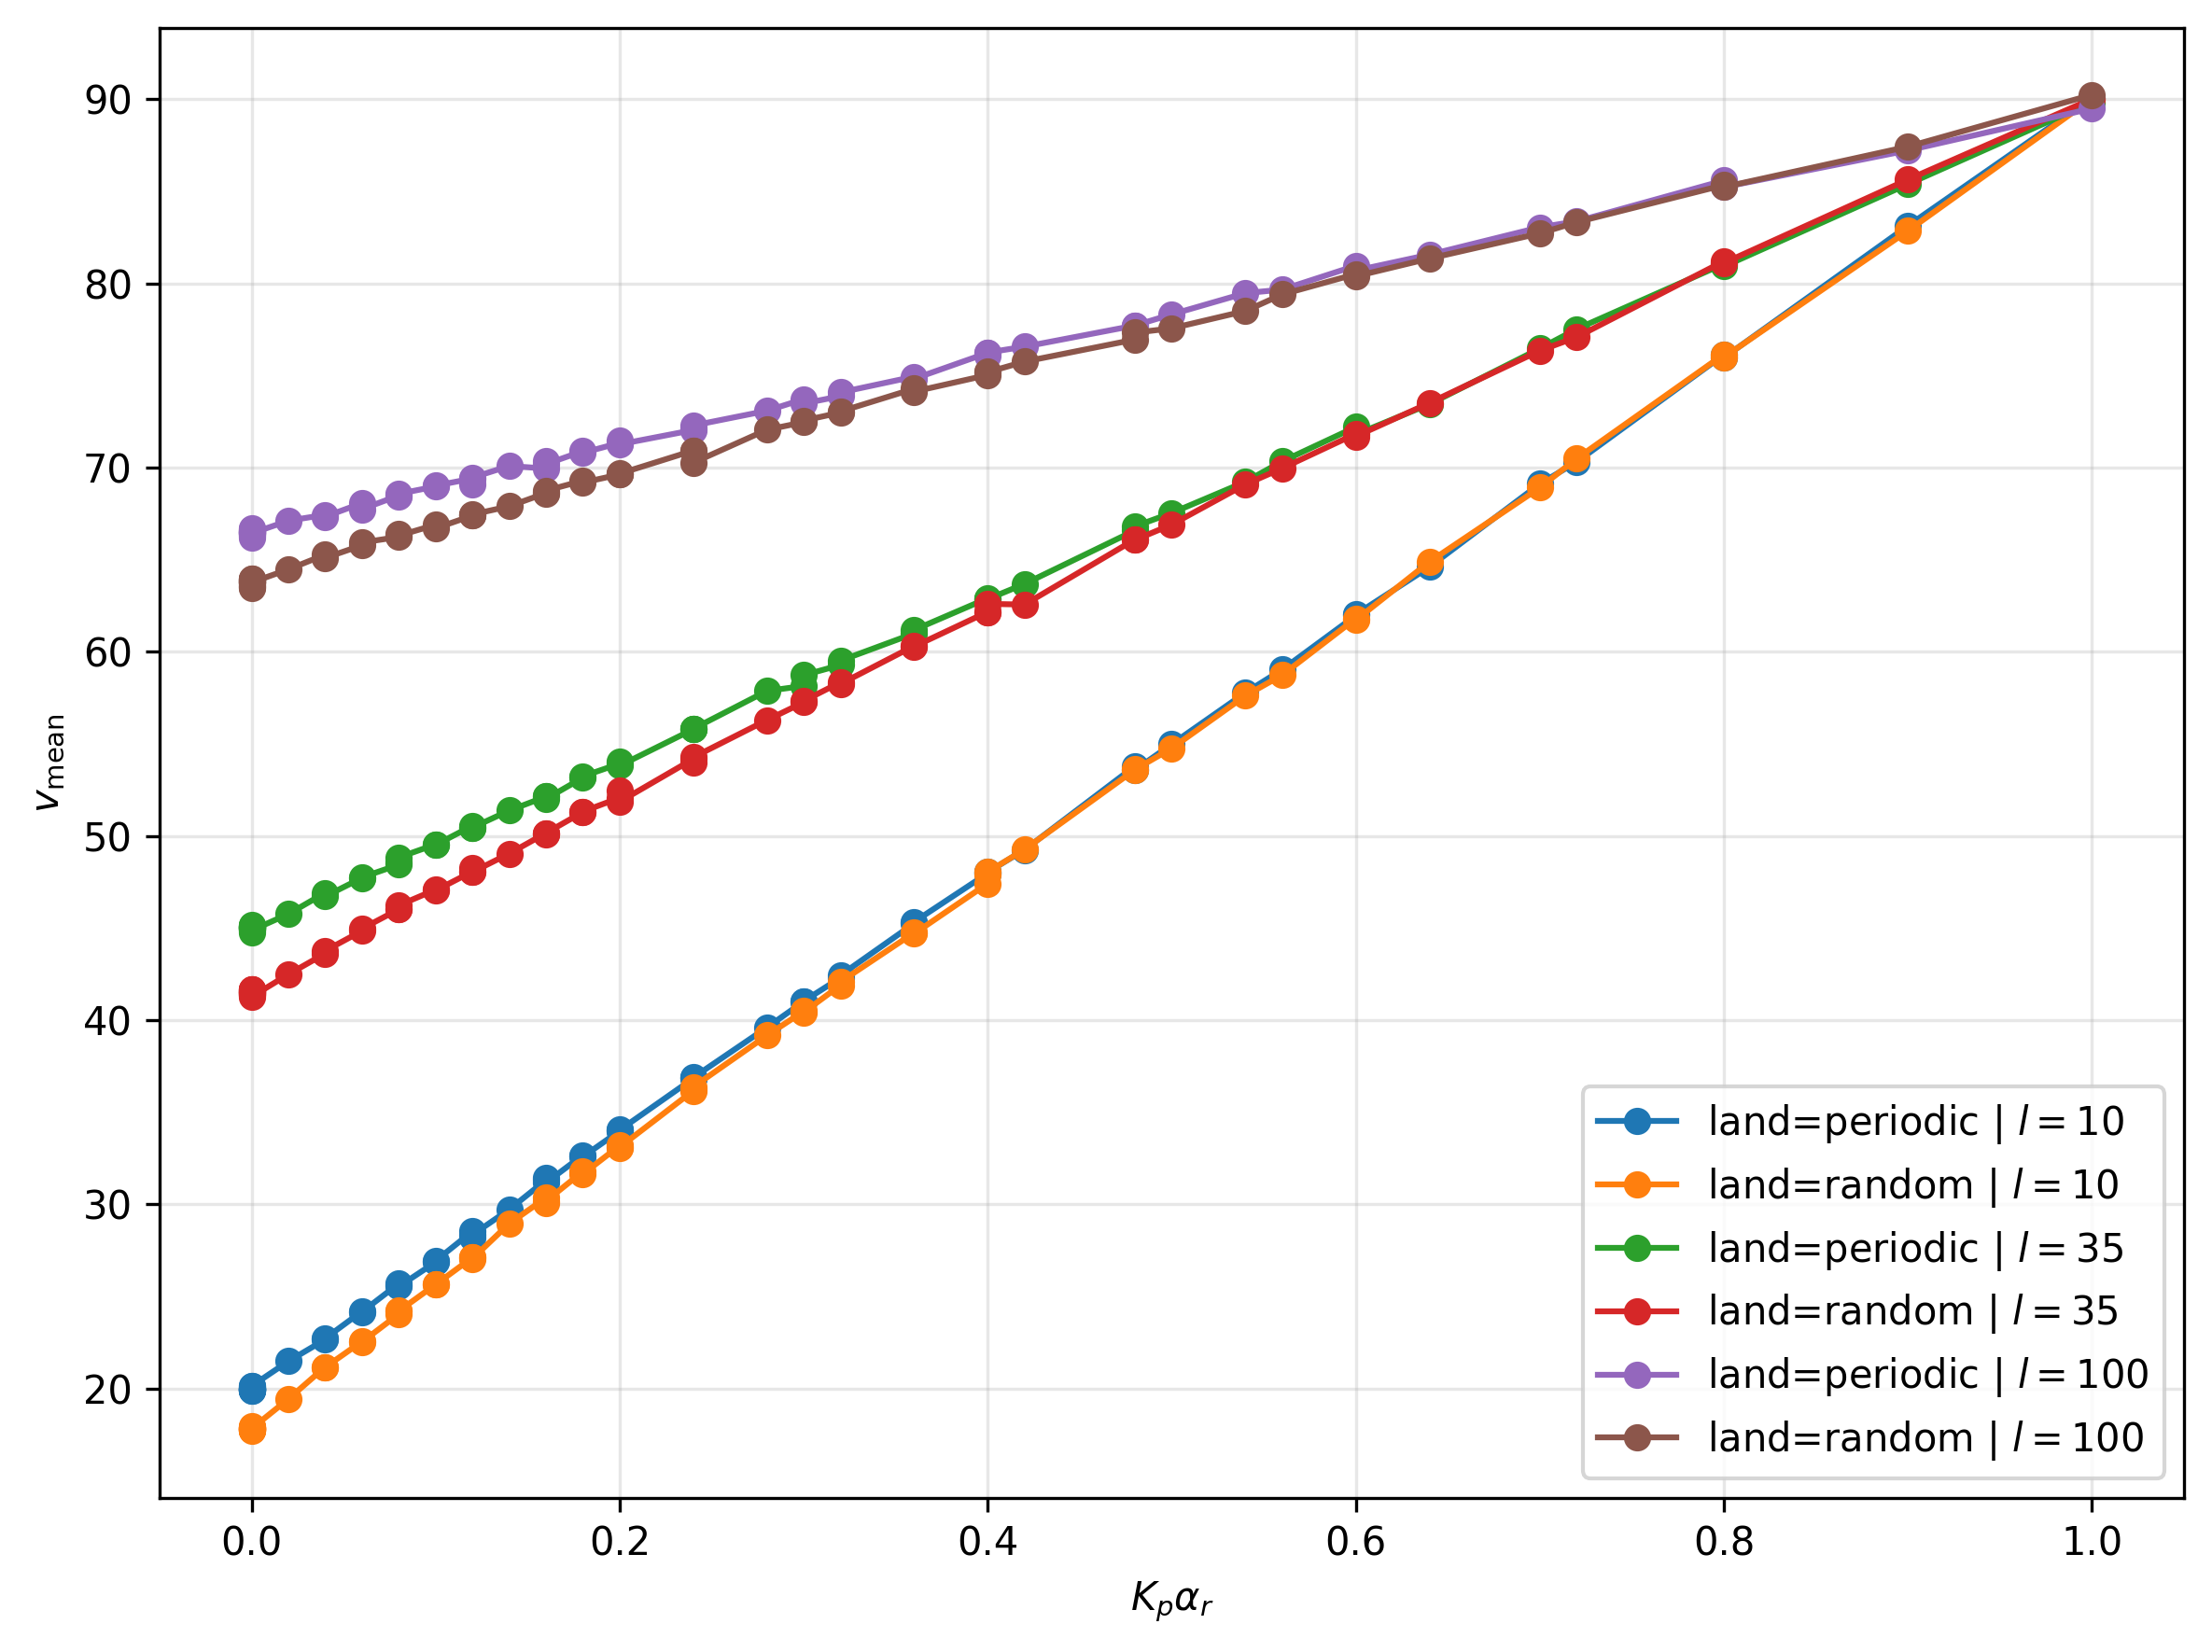

In [7]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

plt.figure(figsize=(8, 6), dpi=300)

ls = np.unique(df_passive["l"].to_numpy())

for l in ls:
    for land in landscapes:

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )

        Kp_alphar = (
            df_land["Kp"].to_numpy()
            * df_land["alphar"].to_numpy()
        )

        v_mean_land = df_land["v_mean"].to_numpy()

        order = np.argsort(Kp_alphar)

        plt.plot(
            Kp_alphar[order],
            v_mean_land[order],
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()

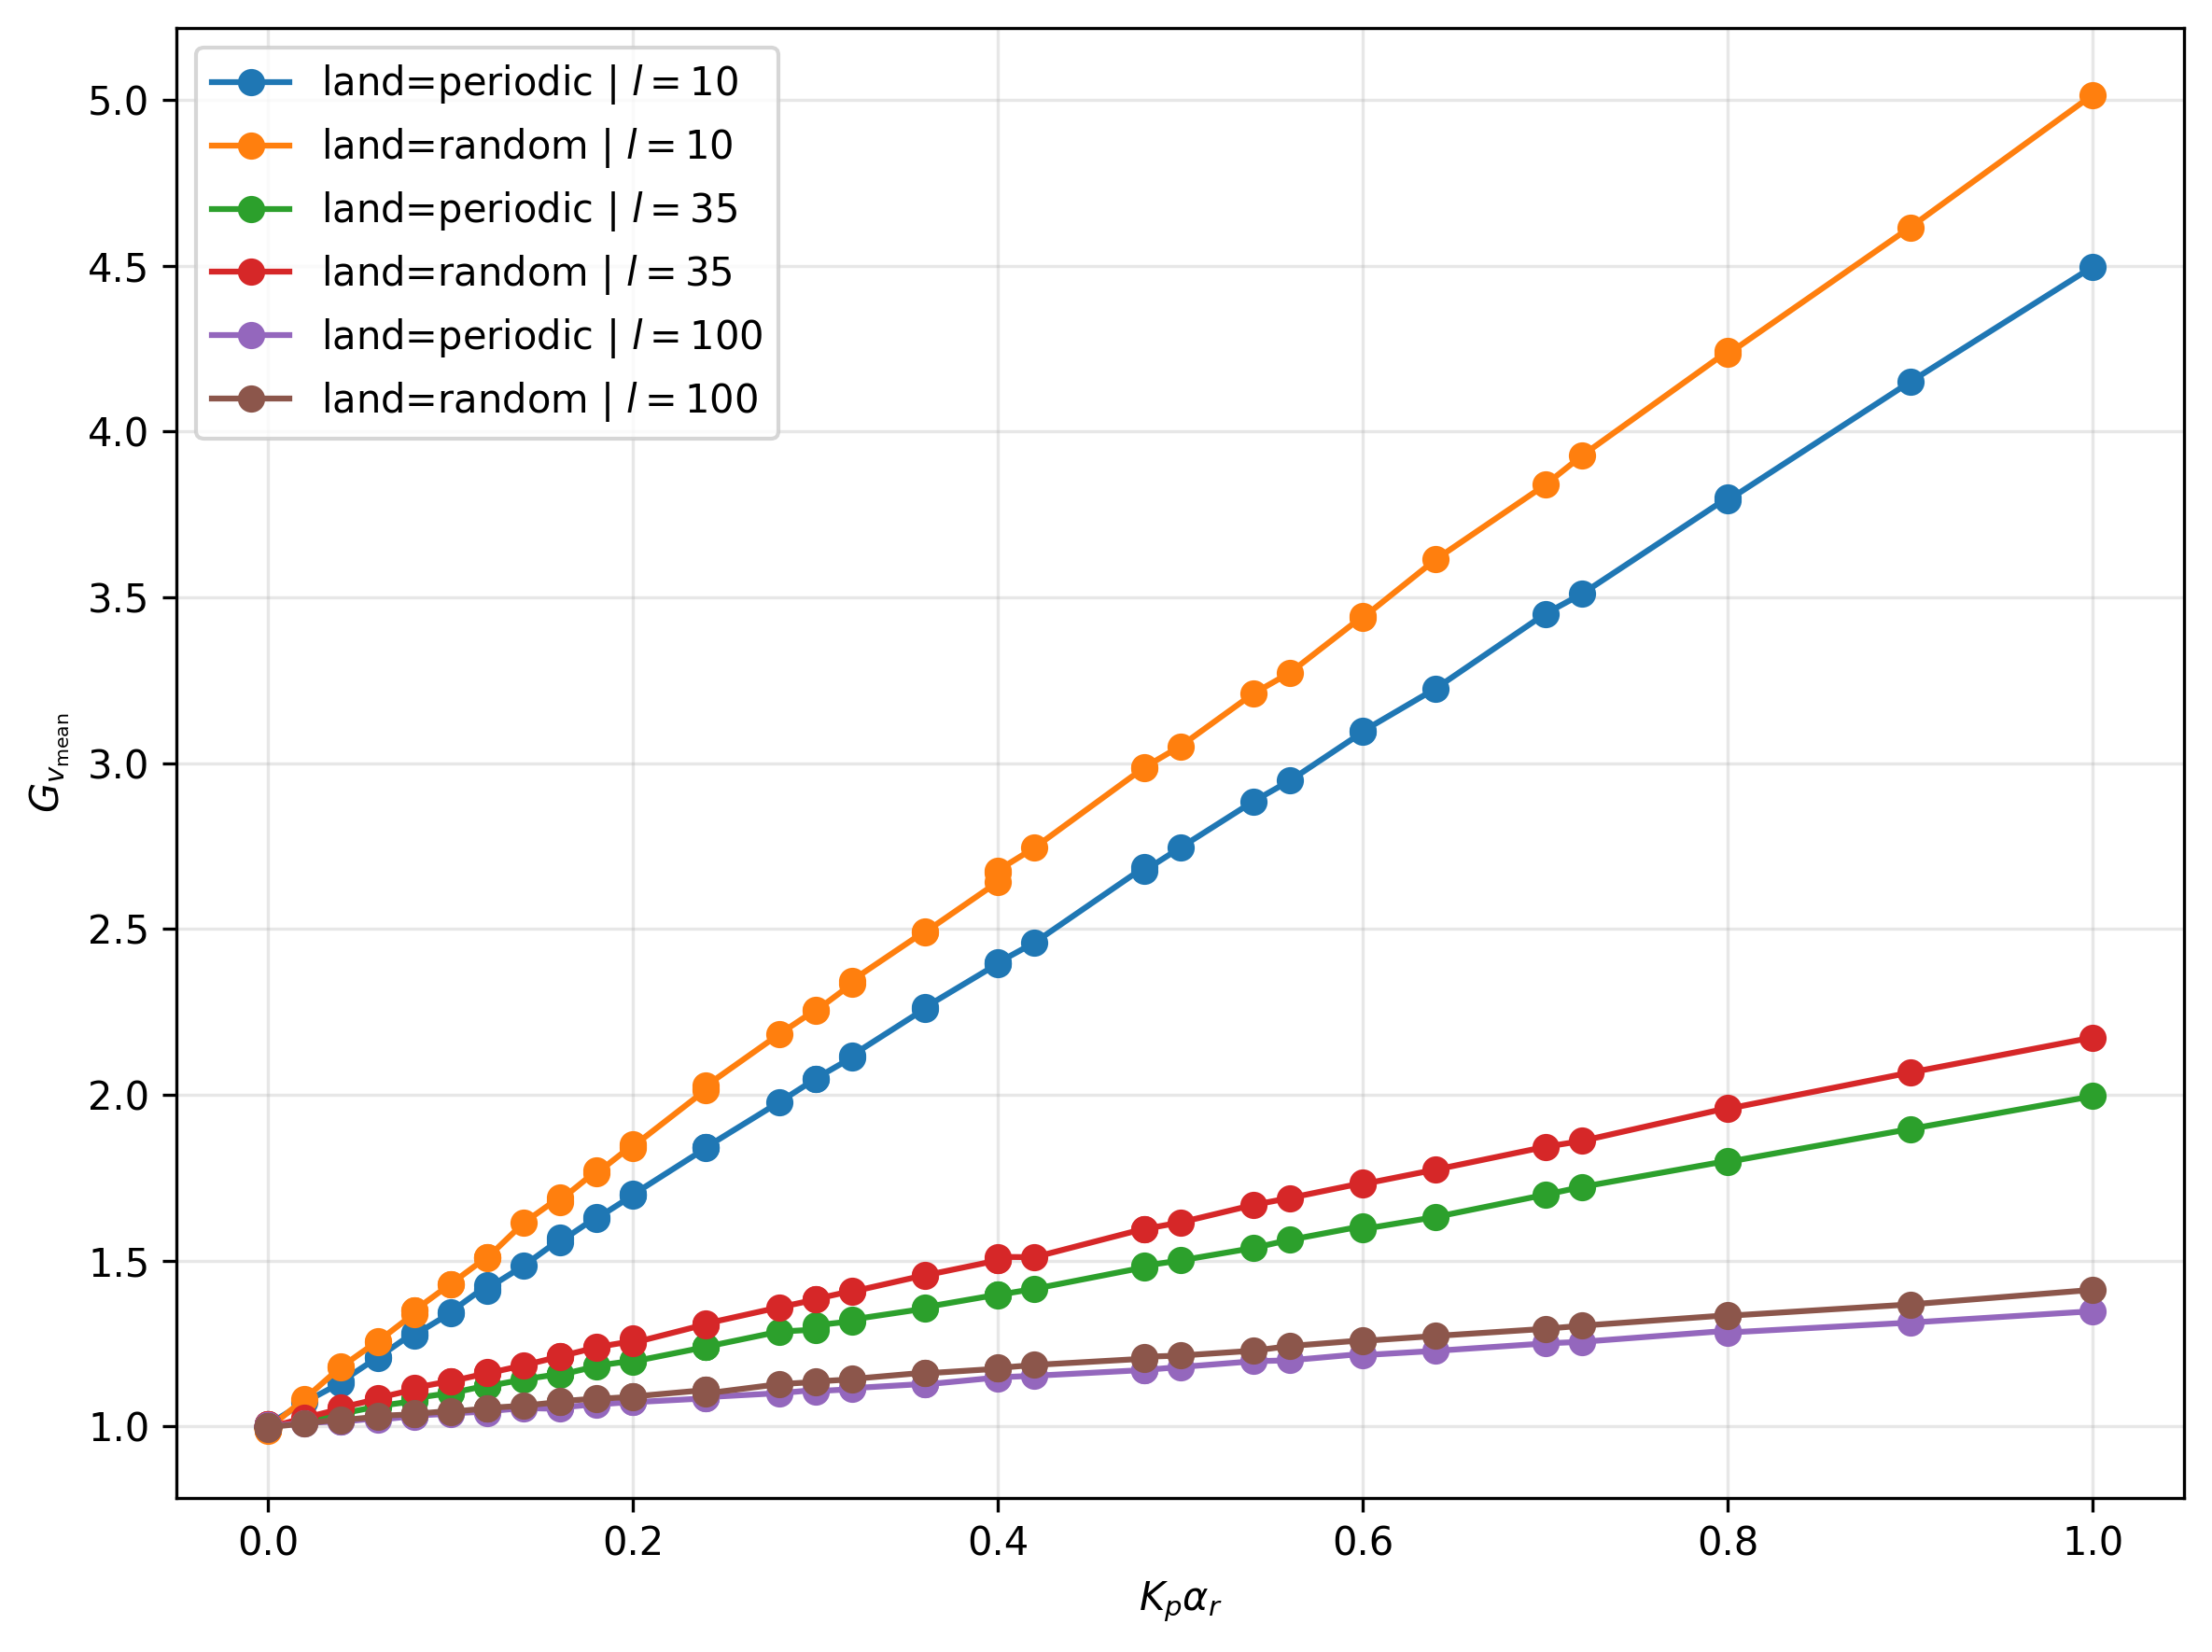

In [8]:
plt.figure(figsize=(8, 6), dpi=300)

ls = np.unique(df_passive["l"].to_numpy())

for l in ls:
    for land in landscapes:

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )

        v_base = df_passive.filter(
            (pl.col("alphar") == 0) &
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )["v_mean"].to_numpy()[0]

        Kp_alphar = (
            df_land["Kp"].to_numpy()
            * df_land["alphar"].to_numpy()
        )

        gain = df_land["v_mean"].to_numpy() / v_base

        order = np.argsort(Kp_alphar)

        plt.plot(
            Kp_alphar[order],
            gain[order],
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$G_{v_{\mathrm{mean}}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()

# Passive : bp

[2.60169286e-01 2.31731820e-01 2.39045994e-01 2.15625931e-01
 2.41737295e-01 2.41708840e-01 2.52919576e-01 2.68964629e-01
 2.52944061e-01 2.28875287e-01 2.22714655e-01 2.33005091e-01
 4.18702878e-01 6.98645277e-01 1.11404615e+00 1.74477757e+00
 2.47897182e+00 3.34817830e+00 4.71682826e+00 6.44887616e+00
 7.83493361e+00 1.05195736e+01 2.33732983e-01 6.41426365e-01
 1.64874440e+00 3.54958663e+00 6.28942583e+00 1.07505121e+01
 1.62929425e+01 2.34712307e+01 3.20543231e+01 4.29250005e+01
 5.43492065e+01 2.65437875e-01 1.08612599e+00 3.36771183e+00
 8.04335789e+00 1.65830172e+01 2.74122497e+01 4.24052366e+01
 6.11681906e+01 8.31269652e+01 1.07838046e+02 1.34290566e+02
 2.37319351e-01 1.62723374e+00 6.39259912e+00 1.62804006e+01
 3.17422281e+01 5.44691985e+01 8.26006792e+01 1.14807114e+02
 1.51519356e+02 1.90137913e+02 2.31152069e+02 2.25984084e-01
 2.32745541e+00 1.05407248e+01 2.75983506e+01 5.49047020e+01
 8.98519811e+01 1.33231890e+02 1.80372018e+02 2.30759579e+02
 2.84322552e+02 3.364292

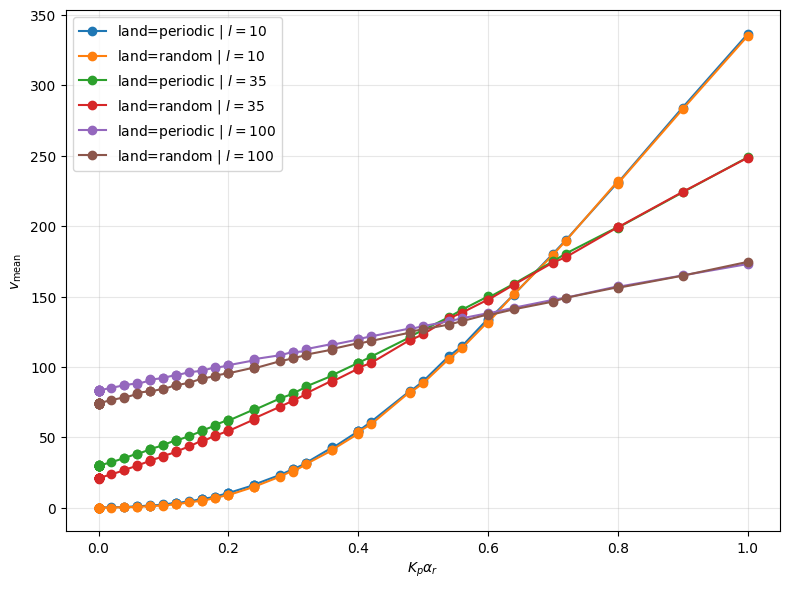

In [12]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

plt.figure(figsize=(8, 6))

ls = np.unique(df_passive["l"].to_numpy())

for l in ls:
    for land in landscapes:

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )

        Kp_alphar = (
            df_land["Kp"].to_numpy()
            * df_land["alphar"].to_numpy()
        )

        v_mean_land = df_land["vc_mean"].to_numpy()
        print(v_mean_land)

        order = np.argsort(Kp_alphar)

        plt.plot(
            Kp_alphar[order],
            v_mean_land[order],
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$v_{\mathrm{mean}}$")
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()

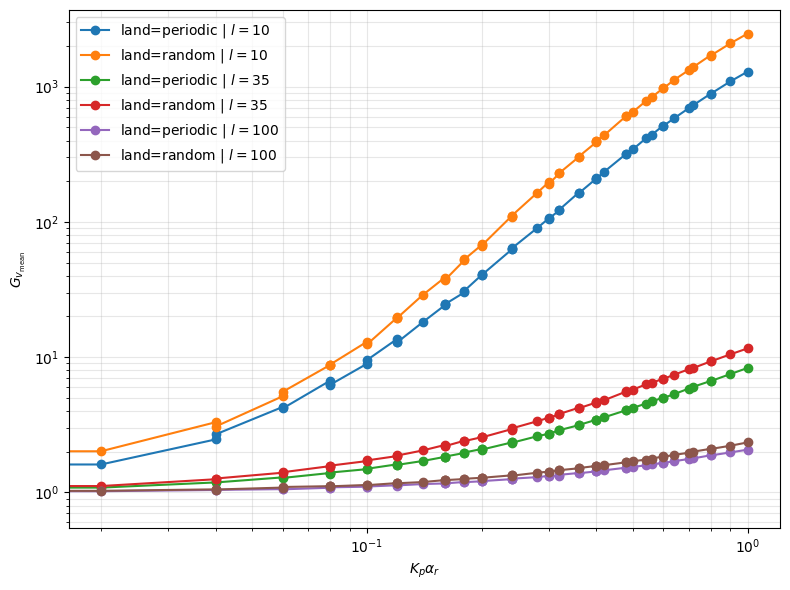

In [13]:
plt.figure(figsize=(8, 6))

ls = np.unique(df_passive["l"].to_numpy())

for l in ls:
    for land in landscapes:

        df_land = df_passive.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )

        v_base = df_passive.filter(
            (pl.col("alphar") == 0) &
            (pl.col("land") == land) &
            (pl.col("l") == l)
        )["vc_mean"].to_numpy()[0]

        Kp_alphar = (
            df_land["Kp"].to_numpy()
            * df_land["alphar"].to_numpy()
        )

        gain = df_land["vc_mean"].to_numpy() / v_base

        order = np.argsort(Kp_alphar)

        plt.plot(
            Kp_alphar[order],
            gain[order],
            marker="o",
            label=f"land={land} | $l={l}$"
        )

plt.xlabel(r"$K_p \alpha_r$")
plt.ylabel(r"$G_{v_{\mathrm{mean}}}$")
plt.grid(True, alpha=0.30, which="both")
plt.loglog(True)
plt.legend()
plt.tight_layout()
plt.show()

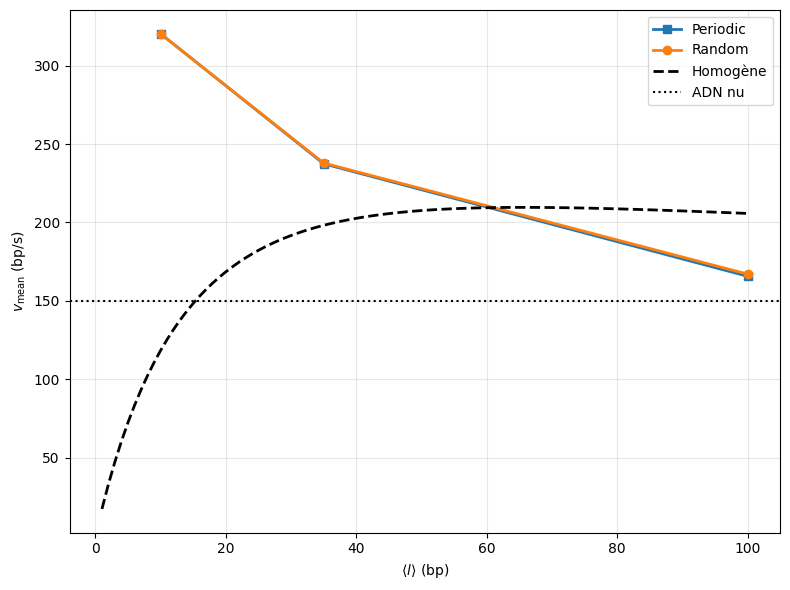

In [11]:
# - En paires de base -----

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

plt.figure(figsize=(8, 6))

s = 35
c_l = 1
c_n = 150 / (10.5 / 0.3)

mu_shot = 150
theta_shot = 100
Kp_shot = 1
alphar_shot = 1

landscapes = ["periodic", "random"]

# Conversion sites/s -> bp/s
def sites_to_bp(v, l):
    compaction = (l * c_l + s * c_n) / (l + s)
    return v * compaction


# Données simulées
for land in landscapes:

    df_land = df_passive.filter(
        (pl.col("land") == land) &
        (pl.col("mu") == mu_shot) &
        (pl.col("theta") == theta_shot) &
        (pl.col("Kp") == Kp_shot) &
        (pl.col("alphar") == alphar_shot)
    )

    if df_land.height == 0:
        continue

    l = df_land["l"].to_numpy()
    v_mean = df_land["v_mean"].to_numpy()

    v_mean_bp = sites_to_bp(v_mean, l)

    order = np.argsort(l)

    l = l[order]
    v_mean_bp = v_mean_bp[order]

    marker = "s" if land == "periodic" else "o"

    plt.plot(
        l,
        v_mean_bp,
        marker=marker,
        lw=2,
        label=land.capitalize()
    )


# Courbe théorique homogène
l_theo = np.arange(1, max(df_passive["l"].to_numpy()) + 1)

v_theo = (
    mu_shot
    * (l_theo / (l_theo + s))
    * ((l_theo * c_l + s * c_n) / (l_theo + s))
)

plt.plot(
    l_theo,
    v_theo,
    "k--",
    lw=2,
    label="Homogène"
)


# ADN nu
plt.axhline(
    mu_shot * c_l,
    color="black",
    ls=":",
    lw=1.5,
    label=r"ADN nu"
)


plt.xlabel(r"$\langle l\rangle$ (bp)")
plt.ylabel(r"$v_{\mathrm{mean}}$ (bp/s)")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'df_periodic_5c' is not defined

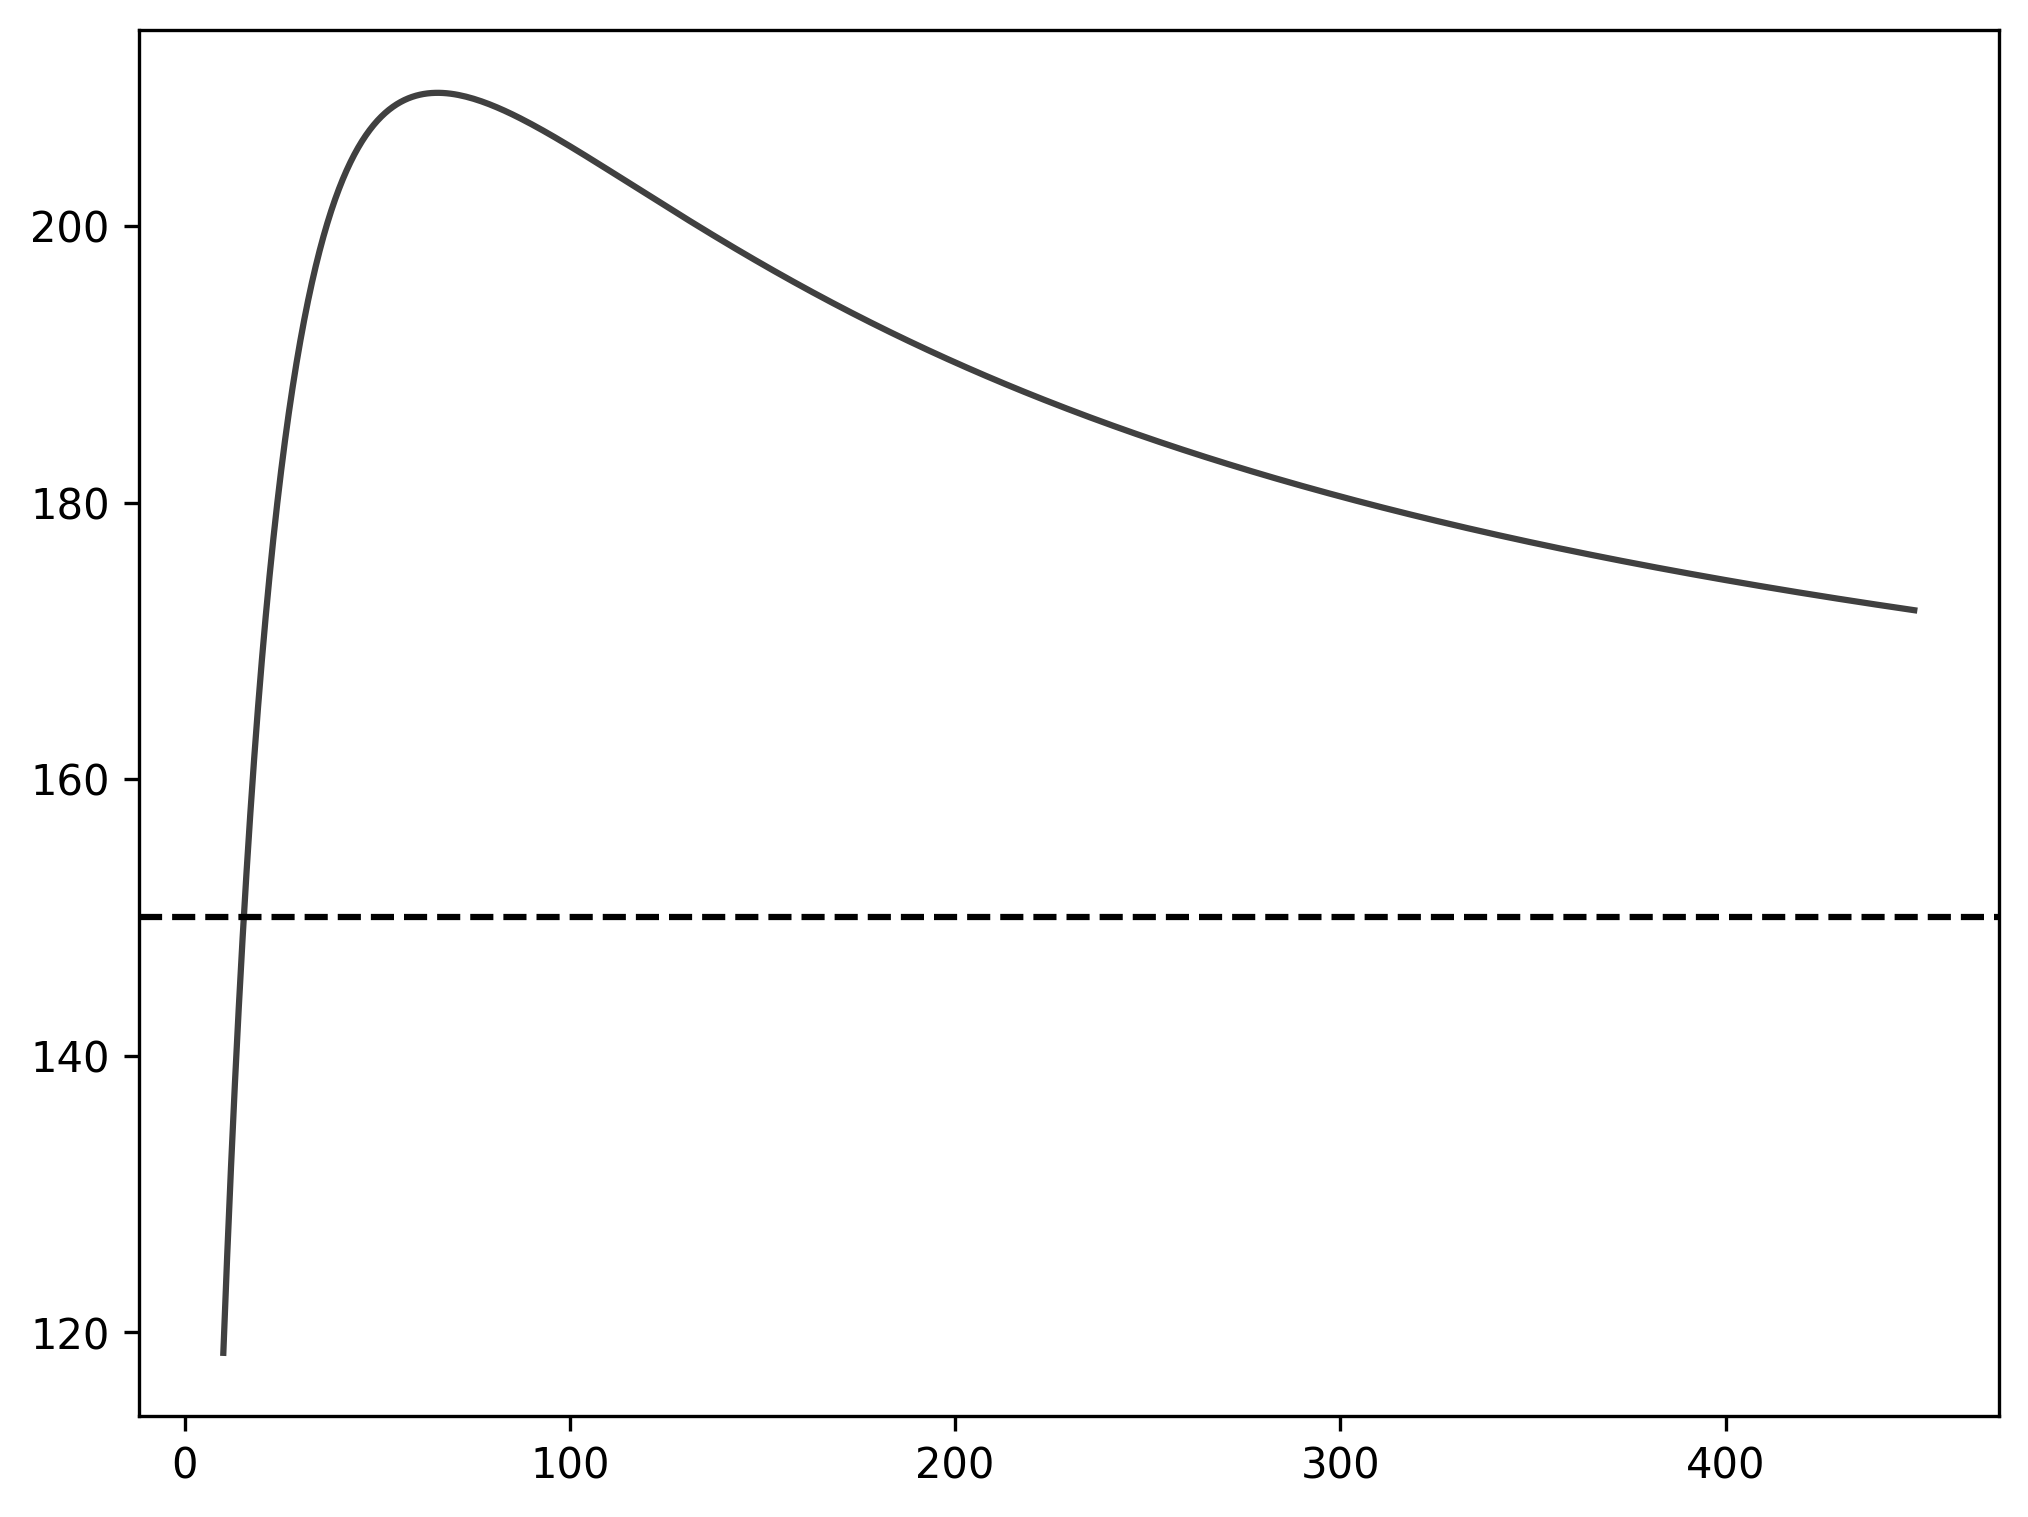

In [12]:
# - En paires de base -----
plt.figure(figsize=(8, 6), dpi=300)


def density(l):
    return (150 + l) / (35 + l)

def compaction(l):
    s = 35
    cl = 1
    cn = 150/(10.5/0.3)
    return ((l * cl + s * cn) / (l + s))

def th_speed_sites(l):
    s = 35
    mu = 150
    return (mu * (l / (l+s)))

def th_speed_bps(l):
    s = 35
    cl = 1
    cn = 150/(10.5/0.3)
    mu = 150
    return (th_speed_sites(l) * (l * cl + s * cn) / (l + s))


mu = 150
theta = 100

plt.axhline(mu, c="k", ls="--", label=r"$v = \mu * c_{l}$")
l_homogen = np.arange(10,450,1)
v_homogen_bps = th_speed_bps(l_homogen)
plt.plot(l_homogen, v_homogen_bps, ls="-", alpha=0.75, label="Homogen", color="black")

for group in df_periodic_5c.partition_by("alphad", as_dict=False):
    alphad = group["alphad"][0]
    # l_mean = group["l_mean"].to_numpy()
    l      = group["l"].to_numpy()
    vc     = group["vc_mean"].to_numpy()
    match  = np.isclose(alphad, alphads_target, atol=1e-6)
    if np.any(match):
        idx = int(np.argmax(match))   # position de cette variante dans alphads_target -> nuance associee
        ax3.plot(l, vc, ls="-", lw=2, alpha=0.75, marker="s",
                  label=rf"Periodic : $\alpha_{{d}} = {alphad:.2f}$", color=shades_periodic[idx])

for group in df_random_5c.partition_by("bpmin", as_dict=False):
    bpmin  = group["bpmin"][0]
    l_mean = group["l"].to_numpy()
    vc     = group["vc_mean"].to_numpy()
    match  = np.isclose(bpmin, bpmins_target, atol=1e-6)
    if np.any(match):
        idx = int(np.argmax(match))   # position de cette variante dans bpmins_target -> nuance associee
        ax3.plot(l_mean, vc, ls="-", lw=2, alpha=0.75, marker="o",
                  label=rf"Random : $bp_{{\min}} = {bpmin}$", color=shades_random[idx])

plt.xlabel(r"$<l>(bp)$")
plt.ylabel(r"$v^{\text{bp}}_{\text{mean}}$")
plt.legend(loc="lower right")
# plt.set_xlim(xlims)
plt.grid(True, alpha=0.30)
plt.show()

# Active full

In [ ]:
# - Actifull -----
df_actifull = df_fact.filter(pl.col("mode") == "actifull")
print(df_actifull)

# Active mémo

In [ ]:
# - Actifull -----
df_actimemo = df_fact.filter(pl.col("mode") == "actimemo")
print(df_actimemo)

# .